# Sparse Input Analysis
## Tables and plots for Chapter 4: Performance on sparse on-grid and out-of-grid input

This notebook loads pre-computed metrics from all sparsity configurations and produces:
1. Summary tables comparing performance across sparsity levels
2. Line plots of key metrics vs. input density (gridded vs. non-gridded)
3. Calibration comparison across sparsity levels
4. Representative prediction images at selected sparsity levels

In [31]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display, Image

METRICS_DIR = Path("trained_models/final-2014-30e-5f")
PLOTS_DIR = METRICS_DIR / "plots"
OUT_DIR = METRICS_DIR / "plots" / "sparse_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOTAL_ERA5_POINTS = 1_769  # ERA5-Land grid cells over Switzerland

# Load all metrics JSON files
records = []
for f in sorted(METRICS_DIR.glob("metrics-*.json")):
    with open(f) as fh:
        d = json.load(fh)
    row = {**d["config"], **d["overall"], **d["correlations"], **d["calibration"], **d["reliability"]}
    records.append(row)

df = pd.DataFrame(records)

# Compute approximate number of context points for percentage-based configs
df["n_points"] = df.apply(
    lambda r: int(round(r["sparsity_value"] * TOTAL_ERA5_POINTS))
    if r["sparsity_type"] == "PERCENT"
    else int(r["sparsity_value"]),
    axis=1,
)

# Split into ERA5 gridded and MeteoSwiss out-of-grid
era5 = df[df["input_data"] == "ERA5_GRID"].sort_values("n_points").reset_index(drop=True)
meteo = df[df["input_data"] == "METEOSWISS"].sort_values("n_points").reset_index(drop=True)

print(f"ERA5 grid configs:    {len(era5)}")
print(f"MeteoSwiss configs:   {len(meteo)}")
print(f"Output directory:     {OUT_DIR}")

ERA5 grid configs:    10
MeteoSwiss configs:   6
Output directory:     trained_models/final-2014-30e-5f/plots/sparse_analysis


## 1. Summary Tables

In [32]:
def format_label(row):
    """Human-readable label for each sparsity configuration."""
    if row["sparsity_type"] == "PERCENT":
        pct = row["sparsity_value"]
        return f"{pct*100:.0f}% ({row['n_points']})"
    return f"{row['n_points']} pts"

def make_summary_table(subset, title):
    """Build and display a styled summary table."""
    tbl = subset.copy()
    tbl["Input density"] = tbl.apply(format_label, axis=1)
    cols = {
        "Input density": "Input density",
        "n_points": "Points",
        "mae": "MAE (°C)",
        "rmse": "RMSE (°C)",
        "bias": "Bias (°C)",
        "crps": "CRPS (°C)",
        "skill_score": "Skill",
        "uncertainty_error": "σ–err corr",
        "z_std": "z-std",
        "coverage_at_90": "90% cov.",
    }
    tbl = tbl[list(cols.keys())].rename(columns=cols)
    print(f"\n{'='*80}")
    print(f"  {title}")
    print(f"{'='*80}")
    display(tbl.style.format({
        "MAE (°C)": "{:.2f}", "RMSE (°C)": "{:.2f}", "Bias (°C)": "{:+.2f}",
        "CRPS (°C)": "{:.2f}", "Skill": "{:.3f}", "σ–err corr": "{:.3f}",
        "z-std": "{:.1f}", "90% cov.": "{:.1%}",
    }).hide(axis="index"))
    return tbl

tbl_era5 = make_summary_table(era5, "ERA5 Grid Sparsity (on-grid)")
tbl_meteo = make_summary_table(meteo, "MeteoSwiss Sparsity (out-of-grid)")


  ERA5 Grid Sparsity (on-grid)


Input density,Points,MAE (°C),RMSE (°C),Bias (°C),CRPS (°C),Skill,σ–err corr,z-std,90% cov.
20 pts,20,4.93,6.09,+1.81,4.83,-0.903,0.111,35.5,4.2%
50 pts,50,3.73,4.66,+1.73,3.63,-0.430,-0.012,27.5,6.2%
80 pts,80,3.20,4.02,+1.69,3.10,-0.223,-0.023,24.0,7.3%
100 pts,100,2.99,3.75,+1.59,2.89,-0.140,-0.026,22.4,8.1%
120 pts,120,2.77,3.48,+1.43,2.67,-0.052,-0.010,20.8,8.6%
10% (177),177,2.27,2.86,+1.01,2.17,0.144,-0.002,17.3,10.2%
25% (442),442,1.51,1.93,+0.20,1.41,0.446,0.272,10.3,14.0%
50% (884),884,1.36,1.77,+0.01,1.26,0.505,0.668,9.0,15.5%
90% (1592),1592,1.31,1.72,-0.04,1.21,0.522,0.736,8.7,16.0%
100% (1769),1769,1.31,1.71,-0.05,1.21,0.524,0.740,8.7,16.1%



  MeteoSwiss Sparsity (out-of-grid)


Input density,Points,MAE (°C),RMSE (°C),Bias (°C),CRPS (°C),Skill,σ–err corr,z-std,90% cov.
20 pts,20,4.77,5.78,+2.05,4.67,-0.840,-0.047,34.4,4.0%
50 pts,50,3.54,4.24,+2.26,3.44,-0.356,-0.178,25.9,5.4%
80 pts,80,2.99,3.56,+1.98,2.89,-0.137,-0.135,21.1,6.4%
100 pts,100,2.84,3.38,+1.86,2.74,-0.079,-0.125,20.3,6.7%
120 pts,120,2.79,3.31,+1.92,2.69,-0.060,-0.128,19.3,6.8%
176 pts,176,2.68,3.16,+2.07,2.58,-0.018,-0.124,17.2,6.9%


### LaTeX table export for the report

In [33]:
def to_latex_table(subset, caption, label):
    """Generate a LaTeX table string for the report."""
    lines = []
    lines.append(r"\begin{table}[H]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{@{}lrrrrrrr@{}}")
    lines.append(r"\toprule")
    lines.append(
        r"\textbf{Input} & \textbf{Points} & \textbf{MAE} & \textbf{RMSE} "
        r"& \textbf{Bias} & \textbf{CRPS} & \textbf{Skill} & \textbf{$\sigma$--err} \\"
    )
    lines.append(
        r"& & (\textdegree C) & (\textdegree C) & (\textdegree C) "
        r"& (\textdegree C) & & corr \\"
    )
    lines.append(r"\midrule")
    for _, r in subset.iterrows():
        lbl = format_label(r)
        bias_sign = "$+$" if r["bias"] >= 0 else "$-$"
        lines.append(
            f"\\quad {lbl} & {r['n_points']} & {r['mae']:.2f} & {r['rmse']:.2f} "
            f"& {bias_sign}{abs(r['bias']):.2f} & {r['crps']:.2f} "
            f"& {r['skill_score']:.3f} & {r['uncertainty_error']:.3f} \\\\"
        )
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

latex_era5 = to_latex_table(
    era5,
    r"Performance with sparse ERA5-Land grid input. The full grid has 1\,769~points.",
    "tab:sparse_era5",
)
latex_meteo = to_latex_table(
    meteo,
    r"Performance with sparse MeteoSwiss (out-of-grid) input. Maximum available: 176~stations.",
    "tab:sparse_meteoswiss",
)

print(latex_era5)
print()
print(latex_meteo)

# Save to files for easy inclusion
(OUT_DIR / "table_sparse_era5.tex").write_text(latex_era5)
(OUT_DIR / "table_sparse_meteoswiss.tex").write_text(latex_meteo)
print(f"\nSaved LaTeX tables to {OUT_DIR}")

\begin{table}[H]
\centering
\caption{Performance with sparse ERA5-Land grid input. The full grid has 1\,769~points.}
\label{tab:sparse_era5}
\begin{tabular}{@{}lrrrrrrr@{}}
\toprule
\textbf{Input} & \textbf{Points} & \textbf{MAE} & \textbf{RMSE} & \textbf{Bias} & \textbf{CRPS} & \textbf{Skill} & \textbf{$\sigma$--err} \\
& & (\textdegree C) & (\textdegree C) & (\textdegree C) & (\textdegree C) & & corr \\
\midrule
\quad 20 pts & 20 & 4.93 & 6.09 & $+$1.81 & 4.83 & -0.903 & 0.111 \\
\quad 50 pts & 50 & 3.73 & 4.66 & $+$1.73 & 3.63 & -0.430 & -0.012 \\
\quad 80 pts & 80 & 3.20 & 4.02 & $+$1.69 & 3.10 & -0.223 & -0.023 \\
\quad 100 pts & 100 & 2.99 & 3.75 & $+$1.59 & 2.89 & -0.140 & -0.026 \\
\quad 120 pts & 120 & 2.77 & 3.48 & $+$1.43 & 2.67 & -0.052 & -0.010 \\
\quad 10% (177) & 177 & 2.27 & 2.86 & $+$1.01 & 2.17 & 0.144 & -0.002 \\
\quad 25% (442) & 442 & 1.51 & 1.93 & $+$0.20 & 1.41 & 0.446 & 0.272 \\
\quad 50% (884) & 884 & 1.36 & 1.77 & $+$0.01 & 1.26 & 0.505 & 0.668 \\
\quad 90% (1

## 2. Line Plots: Metrics vs. Input Density

Dual-panel plots comparing ERA5 on-grid and MeteoSwiss out-of-grid performance as context density varies. The x-axis uses number of context points (log scale) so the two sources are directly comparable.

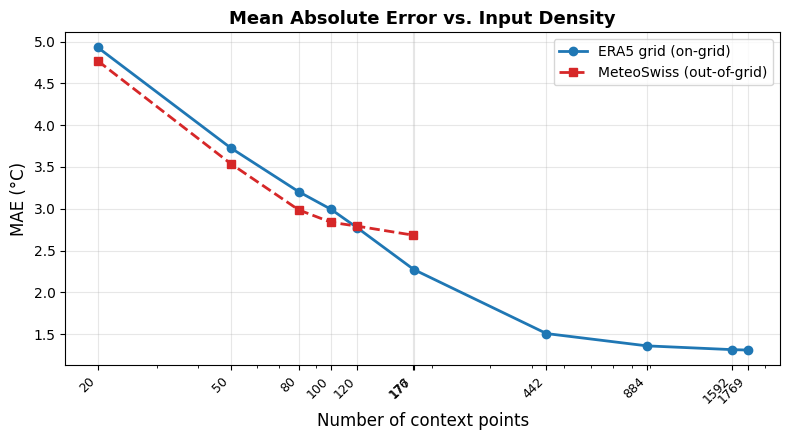

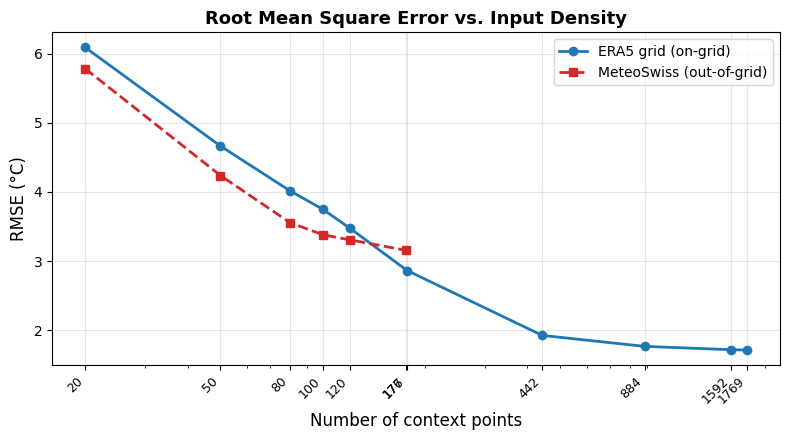

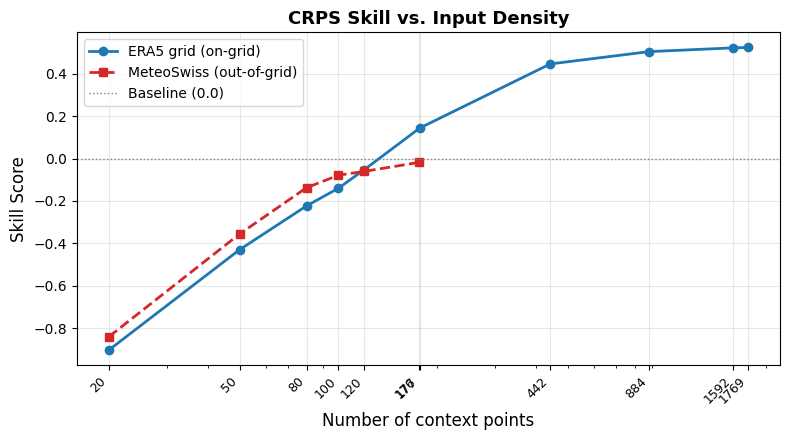

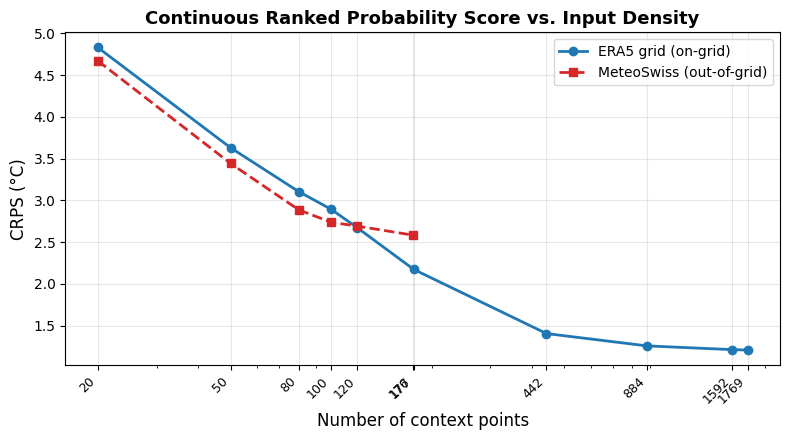

In [34]:
def plot_metric_vs_density(metric, ylabel, title, filename, invert=False, hline=None):
    """Line plot of a single metric vs number of context points for both input types."""
    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.plot(era5["n_points"], era5[metric], "o-", color="#1f77b4", label="ERA5 grid (on-grid)", linewidth=2, markersize=6)
    ax.plot(meteo["n_points"], meteo[metric], "s--", color="#d62728", label="MeteoSwiss (out-of-grid)", linewidth=2, markersize=6)

    if hline is not None:
        ax.axhline(hline, color="gray", linestyle=":", linewidth=1, label=f"Baseline ({hline})")

    ax.set_xscale("log")
    ax.set_xlabel("Number of context points", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Custom x-tick labels at actual data points
    all_pts = sorted(set(era5["n_points"].tolist() + meteo["n_points"].tolist()))
    ax.set_xticks(all_pts)
    ax.set_xticklabels([str(p) for p in all_pts], rotation=45, ha="right", fontsize=9)
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if invert:
        ax.invert_yaxis()

    fig.tight_layout()
    fig.savefig(OUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

# MAE
plot_metric_vs_density("mae", "MAE (°C)", "Mean Absolute Error vs. Input Density", "mae_vs_density.png")

# RMSE
plot_metric_vs_density("rmse", "RMSE (°C)", "Root Mean Square Error vs. Input Density", "rmse_vs_density.png")

# Skill
plot_metric_vs_density("skill_score", "Skill Score", "CRPS Skill vs. Input Density", "skill_vs_density.png", hline=0.0)

# CRPS
plot_metric_vs_density("crps", "CRPS (°C)", "Continuous Ranked Probability Score vs. Input Density", "crps_vs_density.png")

### Combined 2x2 panel for the report

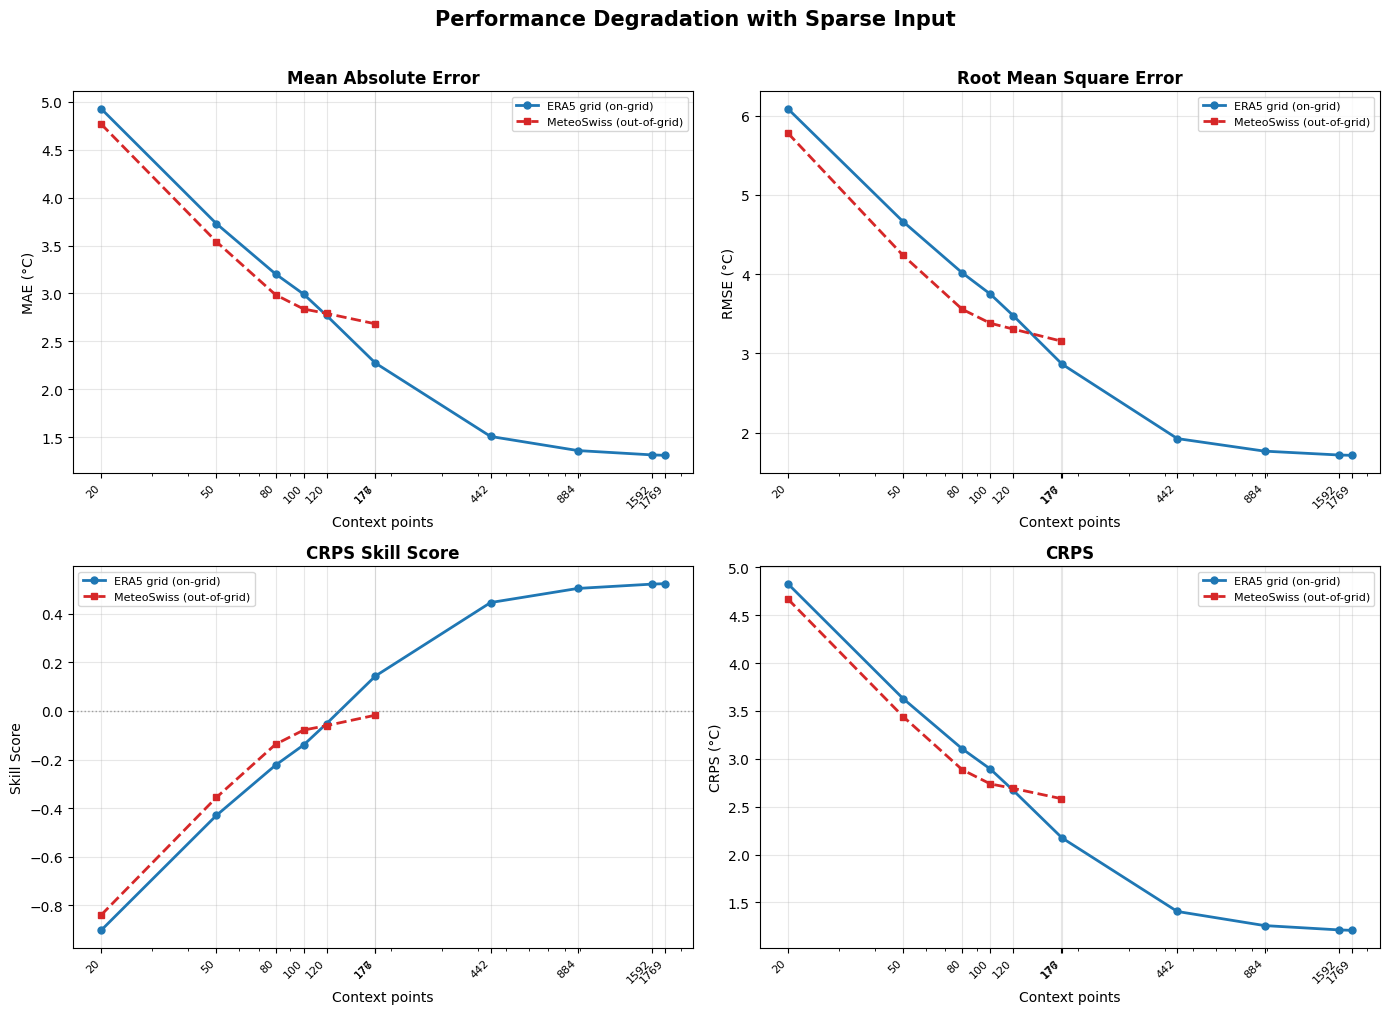

Saved: trained_models/final-2014-30e-5f/plots/sparse_analysis/metrics_vs_density_combined.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_info = [
    ("mae", "MAE (°C)", "Mean Absolute Error"),
    ("rmse", "RMSE (°C)", "Root Mean Square Error"),
    ("skill_score", "Skill Score", "CRPS Skill Score"),
    ("crps", "CRPS (°C)", "CRPS"),
]

for ax, (metric, ylabel, title) in zip(axes.flat, metrics_info):
    ax.plot(era5["n_points"], era5[metric], "o-", color="#1f77b4", label="ERA5 grid (on-grid)", linewidth=2, markersize=5)
    ax.plot(meteo["n_points"], meteo[metric], "s--", color="#d62728", label="MeteoSwiss (out-of-grid)", linewidth=2, markersize=5)

    if metric == "skill_score":
        ax.axhline(0.0, color="gray", linestyle=":", linewidth=1, alpha=0.7)

    ax.set_xscale("log")
    ax.set_xlabel("Context points")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    all_pts = sorted(set(era5["n_points"].tolist() + meteo["n_points"].tolist()))
    ax.set_xticks(all_pts)
    ax.set_xticklabels([str(p) for p in all_pts], rotation=45, ha="right", fontsize=8)
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

fig.suptitle("Performance Degradation with Sparse Input", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "metrics_vs_density_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'metrics_vs_density_combined.png'}")

### Bias and uncertainty-error correlation vs density

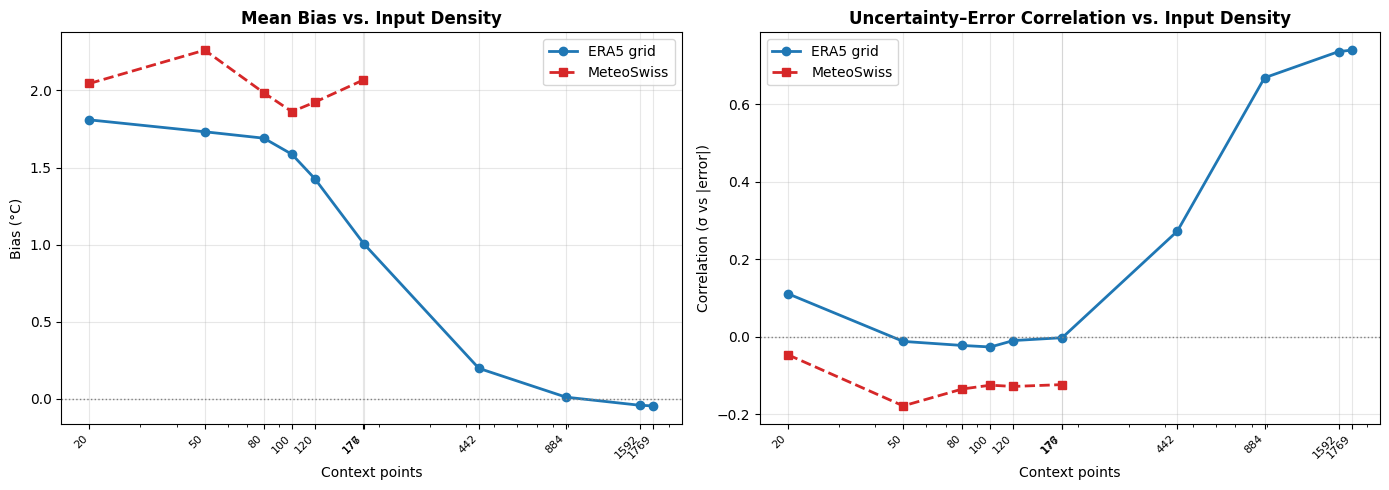

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bias
ax1.plot(era5["n_points"], era5["bias"], "o-", color="#1f77b4", label="ERA5 grid", linewidth=2, markersize=6)
ax1.plot(meteo["n_points"], meteo["bias"], "s--", color="#d62728", label="MeteoSwiss", linewidth=2, markersize=6)
ax1.axhline(0.0, color="gray", linestyle=":", linewidth=1)
ax1.set_xscale("log")
ax1.set_xlabel("Context points")
ax1.set_ylabel("Bias (°C)")
ax1.set_title("Mean Bias vs. Input Density", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)
all_pts = sorted(set(era5["n_points"].tolist() + meteo["n_points"].tolist()))
ax1.set_xticks(all_pts)
ax1.set_xticklabels([str(p) for p in all_pts], rotation=45, ha="right", fontsize=8)
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())

# Uncertainty-error correlation
ax2.plot(era5["n_points"], era5["uncertainty_error"], "o-", color="#1f77b4", label="ERA5 grid", linewidth=2, markersize=6)
ax2.plot(meteo["n_points"], meteo["uncertainty_error"], "s--", color="#d62728", label="MeteoSwiss", linewidth=2, markersize=6)
ax2.axhline(0.0, color="gray", linestyle=":", linewidth=1)
ax2.set_xscale("log")
ax2.set_xlabel("Context points")
ax2.set_ylabel("Correlation (σ vs |error|)")
ax2.set_title("Uncertainty–Error Correlation vs. Input Density", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(all_pts)
ax2.set_xticklabels([str(p) for p in all_pts], rotation=45, ha="right", fontsize=8)
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())

fig.tight_layout()
fig.savefig(OUT_DIR / "bias_uncertainty_vs_density.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Calibration Comparison across Sparsity Levels

How does the model's uncertainty calibration change as context density decreases?

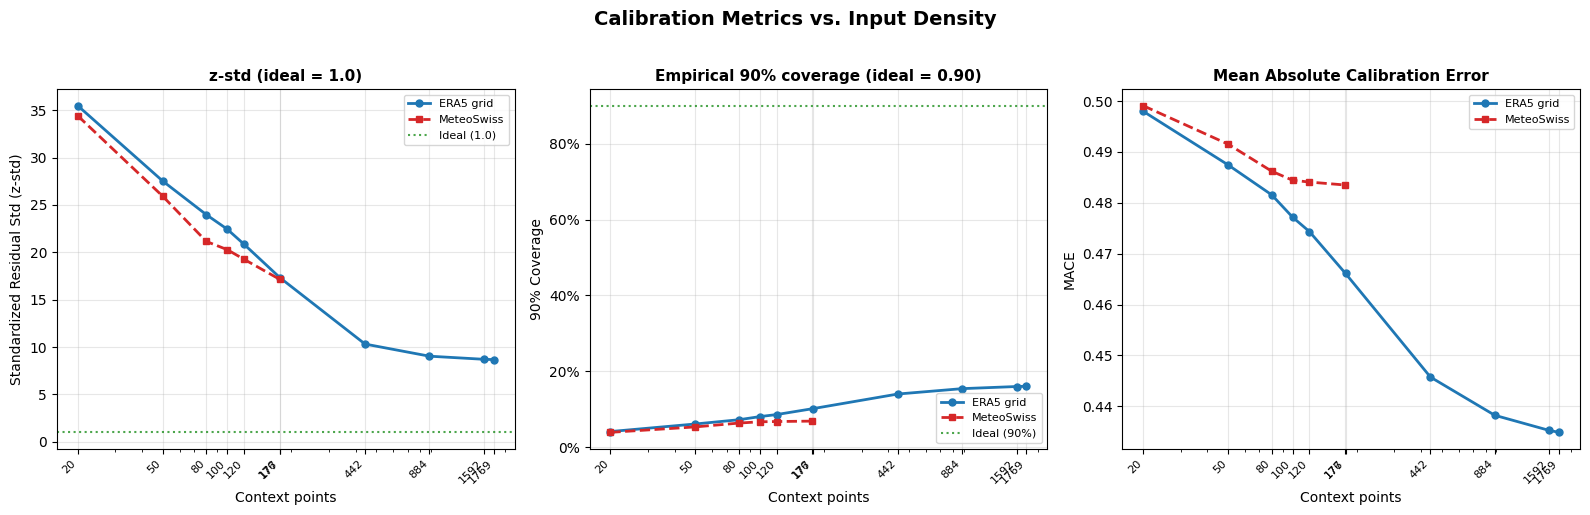

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

calib_metrics = [
    ("z_std", "Standardized Residual Std (z-std)", "z-std (ideal = 1.0)"),
    ("coverage_at_90", "90% Coverage", "Empirical 90% coverage (ideal = 0.90)"),
    ("mace", "MACE", "Mean Absolute Calibration Error"),
]

for ax, (metric, ylabel, title) in zip(axes, calib_metrics):
    ax.plot(era5["n_points"], era5[metric], "o-", color="#1f77b4", label="ERA5 grid", linewidth=2, markersize=5)
    ax.plot(meteo["n_points"], meteo[metric], "s--", color="#d62728", label="MeteoSwiss", linewidth=2, markersize=5)

    if metric == "z_std":
        ax.axhline(1.0, color="green", linestyle=":", linewidth=1.5, alpha=0.7, label="Ideal (1.0)")
    elif metric == "coverage_at_90":
        ax.axhline(0.90, color="green", linestyle=":", linewidth=1.5, alpha=0.7, label="Ideal (90%)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    ax.set_xscale("log")
    ax.set_xlabel("Context points")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    all_pts = sorted(set(era5["n_points"].tolist() + meteo["n_points"].tolist()))
    ax.set_xticks(all_pts)
    ax.set_xticklabels([str(p) for p in all_pts], rotation=45, ha="right", fontsize=8)
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

fig.suptitle("Calibration Metrics vs. Input Density", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "calibration_vs_density.png", dpi=150, bbox_inches="tight")
plt.show()

### Q-Q calibration plot grid (existing plots from predictions pipeline)

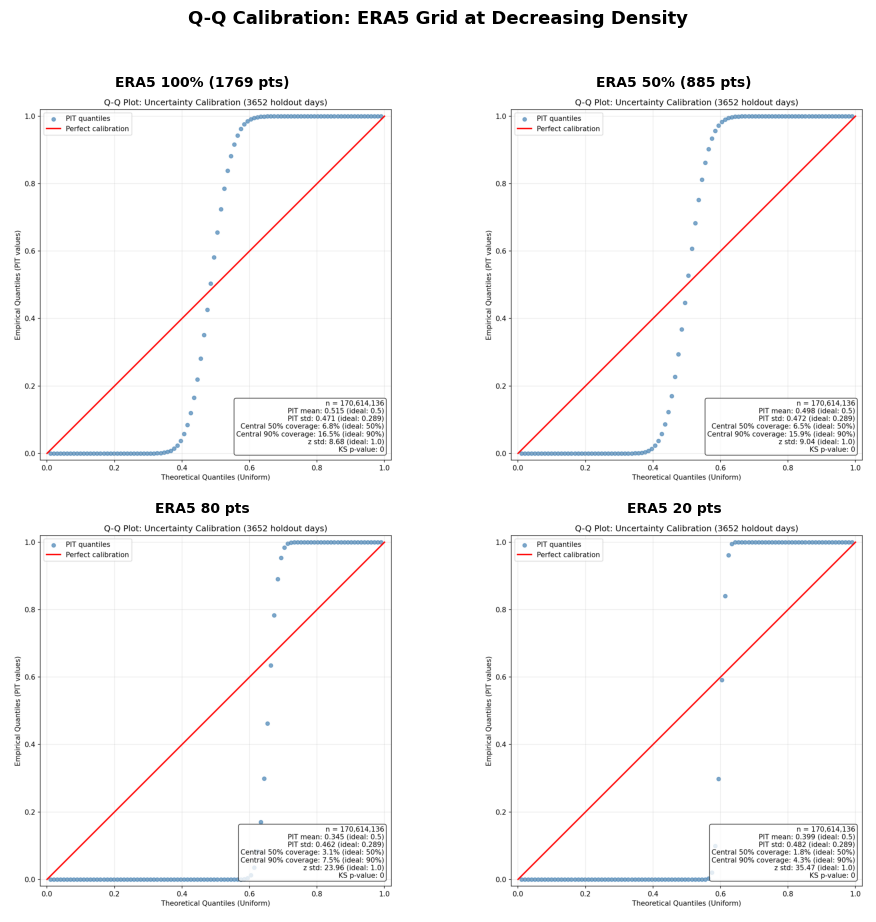

In [38]:
# Show Q-Q calibration plots for selected ERA5 sparsity levels (2x2 grid)
era5_qq_levels = [
    ("PERCENT", "1.0", "100% (1769 pts)"),
    ("PERCENT", "0.5", "50% (885 pts)"),
    ("ABSOLUTE", "80", "80 pts"),
    ("ABSOLUTE", "20", "20 pts"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (stype, sval, label) in zip(axes.flat, era5_qq_levels):
    img_path = PLOTS_DIR / f"ERA5_GRID_{stype}_{sval}_qq_calibration.png"
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img)
        ax.set_title(f"ERA5 {label}", fontsize=10, fontweight="bold")
    else:
        ax.text(0.5, 0.5, f"Not found:\n{img_path.name}", ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

fig.suptitle("Q-Q Calibration: ERA5 Grid at Decreasing Density", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "qq_era5_sparsity_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Representative Prediction Images

Showing fold 4 predictions at selected sparsity levels to visually demonstrate degradation.

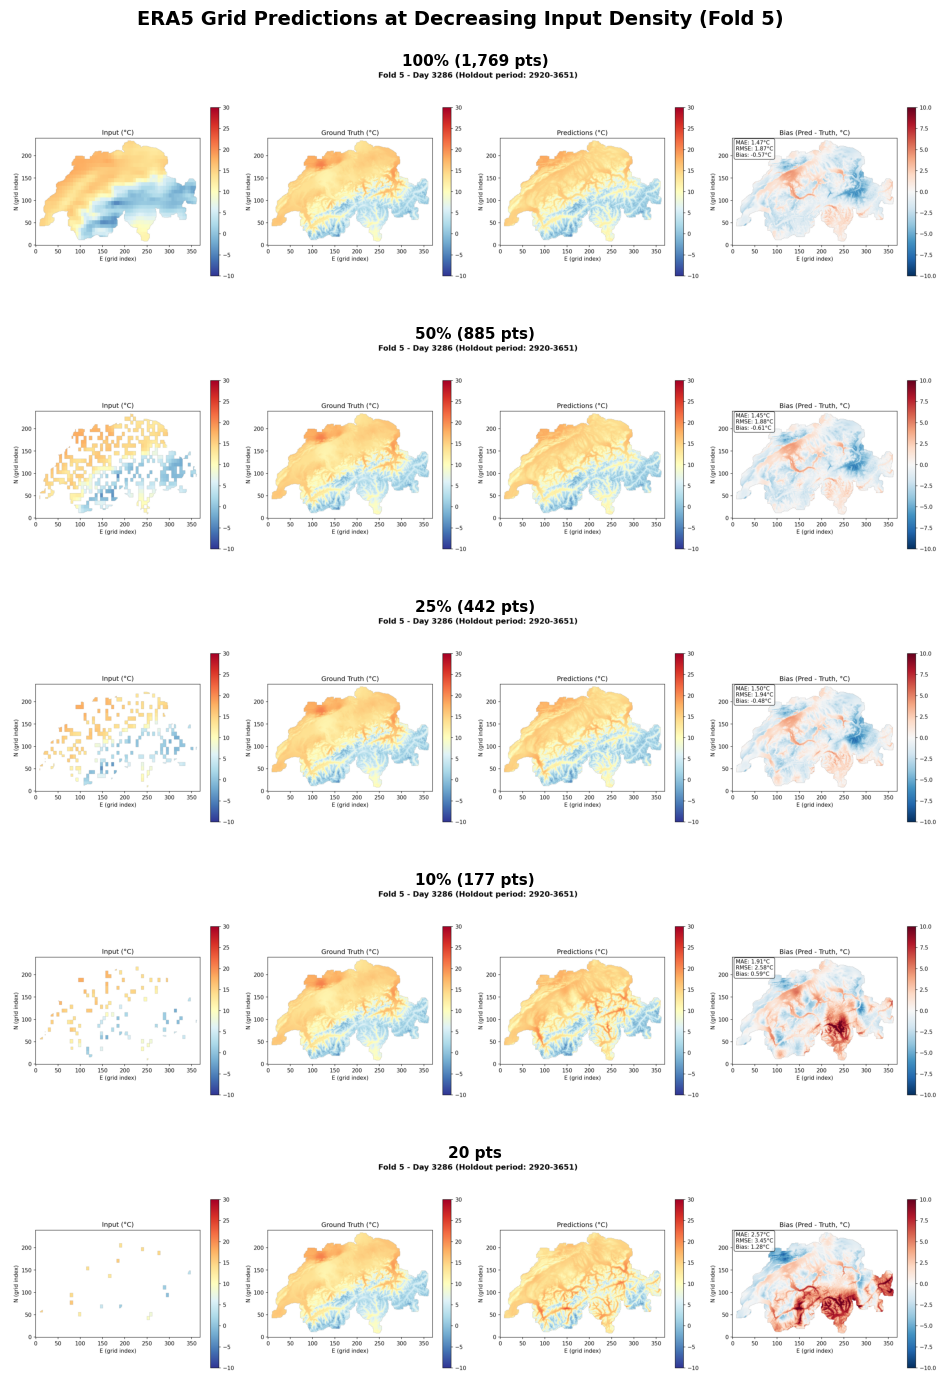

In [39]:
def show_prediction_grid(configs, suptitle, filename, fold=4):
    """Display a column of prediction images (one per row) for given sparsity configs."""
    n = len(configs)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n))
    if n == 1:
        axes = [axes]

    for ax, (input_type, stype, sval, label) in zip(axes, configs):
        img_path = PLOTS_DIR / f"{input_type}_{stype}_{sval}_fold{fold}_prediction.png"
        if img_path.exists():
            img = plt.imread(str(img_path))
            ax.imshow(img)
            ax.set_title(label, fontsize=11, fontweight="bold", pad=2)
        else:
            ax.text(0.5, 0.5, f"Not found:\n{img_path.name}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9)
            ax.set_title(label, fontsize=11, pad=2)
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    fig.subplots_adjust(hspace=0.02, top=0.96)
    fig.savefig(OUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

# ERA5 Grid predictions at key sparsity levels
era5_pred_configs = [
    ("ERA5_GRID", "PERCENT", "1.0", "100% (1,769 pts)"),
    ("ERA5_GRID", "PERCENT", "0.5", "50% (885 pts)"),
    ("ERA5_GRID", "PERCENT", "0.25", "25% (442 pts)"),
    ("ERA5_GRID", "PERCENT", "0.1", "10% (177 pts)"),
    ("ERA5_GRID", "ABSOLUTE", "20", "20 pts"),
]
show_prediction_grid(era5_pred_configs,
                     "ERA5 Grid Predictions at Decreasing Input Density (Fold 5)",
                     "predictions_era5_sparsity.png")

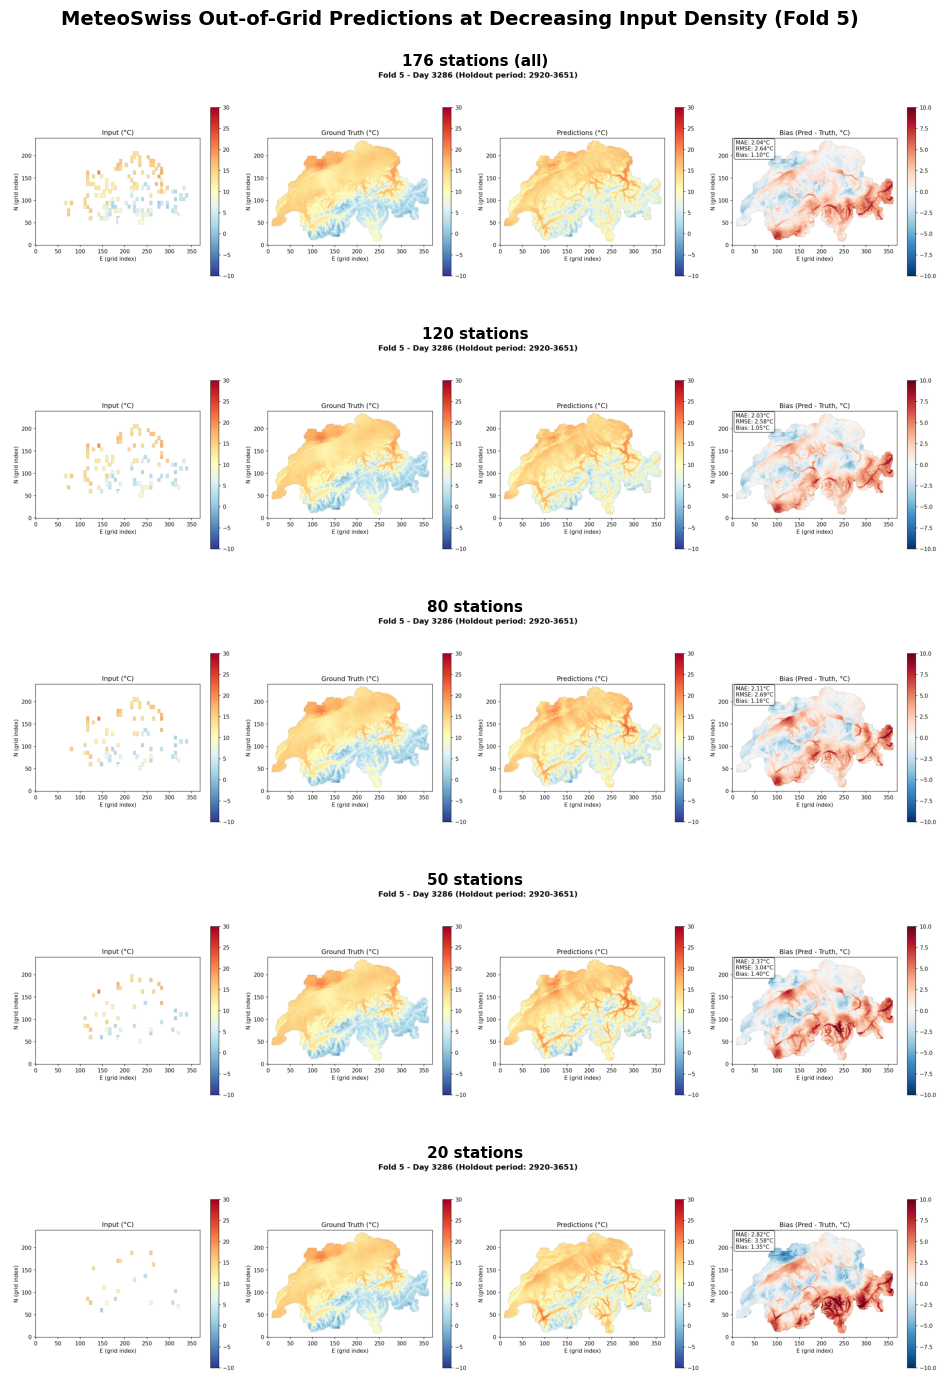

In [40]:
# MeteoSwiss predictions at key sparsity levels
meteo_pred_configs = [
    ("METEOSWISS", "ABSOLUTE", "176", "176 stations (all)"),
    ("METEOSWISS", "ABSOLUTE", "120", "120 stations"),
    ("METEOSWISS", "ABSOLUTE", "80", "80 stations"),
    ("METEOSWISS", "ABSOLUTE", "50", "50 stations"),
    ("METEOSWISS", "ABSOLUTE", "20", "20 stations"),
]
show_prediction_grid(meteo_pred_configs,
                     "MeteoSwiss Out-of-Grid Predictions at Decreasing Input Density (Fold 5)",
                     "predictions_meteoswiss_sparsity.png")

### Error maps comparison: ERA5 on-grid vs MeteoSwiss at comparable point counts

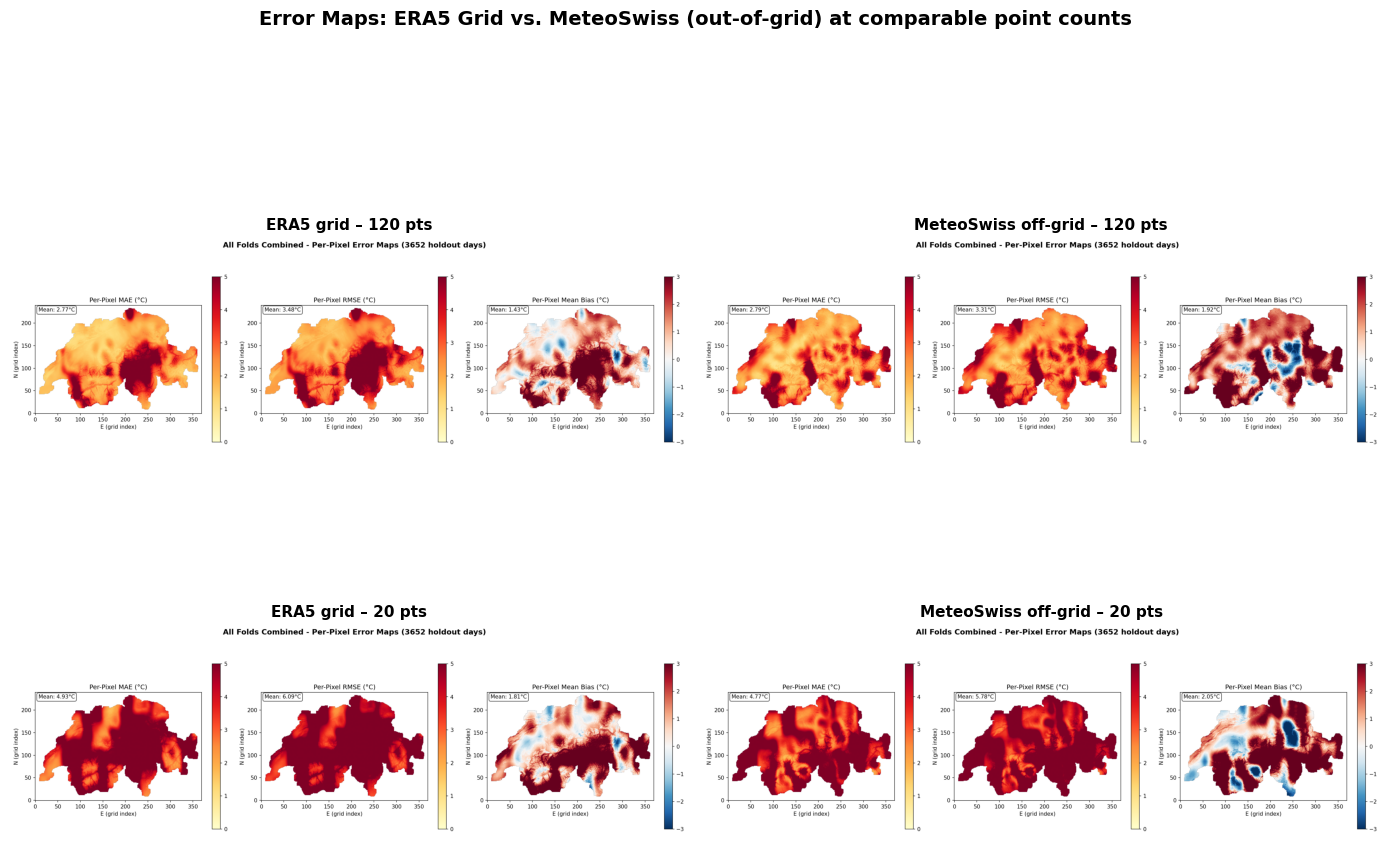

In [41]:
# Compare error maps at ~120 and ~20 points: ERA5 grid vs MeteoSwiss
comparison_pairs = [
    [("ERA5_GRID", "ABSOLUTE", "120", "ERA5 grid – 120 pts"),
     ("METEOSWISS", "ABSOLUTE", "120", "MeteoSwiss off-grid – 120 pts")],
    [("ERA5_GRID", "ABSOLUTE", "20", "ERA5 grid – 20 pts"),
     ("METEOSWISS", "ABSOLUTE", "20", "MeteoSwiss off-grid – 20 pts")],
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, pair in enumerate(comparison_pairs):
    for col_idx, (input_type, stype, sval, label) in enumerate(pair):
        ax = axes[row_idx, col_idx]
        img_path = PLOTS_DIR / f"{input_type}_{stype}_{sval}_error_maps.png"
        if img_path.exists():
            img = plt.imread(str(img_path))
            ax.imshow(img)
            ax.set_title(label, fontsize=11, fontweight="bold")
        else:
            ax.text(0.5, 0.5, f"Not found:\n{img_path.name}", ha="center",
                    va="center", transform=ax.transAxes)
        ax.axis("off")

fig.suptitle("Error Maps: ERA5 Grid vs. MeteoSwiss (out-of-grid) at comparable point counts",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "error_maps_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Summary of Key Findings

Quantitative summary extracted from the data for use in the report narrative.

In [42]:
# Baseline (full grid)
base = era5[era5["sparsity_value"] == 1.0].iloc[0]

print("=" * 80)
print("  KEY FINDINGS FOR CHAPTER 4")
print("=" * 80)

print("\n--- ERA5 On-Grid Sparsity ---")
for _, r in era5.iterrows():
    lbl = format_label(r)
    mae_delta = (r["mae"] - base["mae"]) / base["mae"] * 100
    print(f"  {lbl:>20s}:  MAE={r['mae']:.2f}°C ({mae_delta:+.1f}%)  "
          f"Skill={r['skill_score']:.3f}  σ-corr={r['uncertainty_error']:.3f}")

print(f"\n  Graceful degradation zone: 100%→50% grid causes only "
      f"{(era5[era5['sparsity_value']==0.5].iloc[0]['mae'] - base['mae'])/base['mae']*100:.1f}% MAE increase")

era5_50 = era5[era5["sparsity_value"] == 0.5].iloc[0]
era5_25 = era5[era5["sparsity_value"] == 0.25].iloc[0]
era5_10 = era5[era5["sparsity_value"] == 0.1].iloc[0]
print(f"  At 25% grid ({era5_25['n_points']} pts): skill still positive ({era5_25['skill_score']:.3f})")
print(f"  At 10% grid ({era5_10['n_points']} pts): skill drops to {era5_10['skill_score']:.3f}, "
      f"uncertainty correlation collapses ({era5_10['uncertainty_error']:.3f})")

# Find crossover to negative skill for ERA5
era5_neg = era5[era5["skill_score"] < 0]
if len(era5_neg) > 0:
    first_neg = era5_neg.iloc[-1]  # sorted ascending by n_points, so last negative is highest
    last_pos = era5[era5["skill_score"] >= 0].iloc[0]
    print(f"  Skill crosses zero between {last_pos['n_points']} and "
          f"{first_neg['n_points']} ERA5 grid points")

print("\n--- MeteoSwiss Out-of-Grid ---")
for _, r in meteo.iterrows():
    lbl = format_label(r)
    print(f"  {lbl:>20s}:  MAE={r['mae']:.2f}°C  Skill={r['skill_score']:.3f}  "
          f"Bias={r['bias']:+.2f}°C")

meteo_best = meteo[meteo["sparsity_value"] == 176].iloc[0]
print(f"\n  Even with all 176 stations, MeteoSwiss input yields negative skill "
      f"({meteo_best['skill_score']:.3f})")
print(f"  Persistent warm bias across all MeteoSwiss configs "
      f"({meteo['bias'].min():.2f} to {meteo['bias'].max():.2f}°C)")
print(f"  Uncertainty estimates are uninformative (σ-err correlation: "
      f"{meteo_best['uncertainty_error']:.3f})")

print("\n--- On-Grid vs Out-of-Grid at Same Point Count ---")
for n in [120, 100, 80, 50, 20]:
    e = era5[era5["n_points"] == n]
    m = meteo[meteo["n_points"] == n]
    if len(e) > 0 and len(m) > 0:
        e, m = e.iloc[0], m.iloc[0]
        print(f"  {n:3d} pts:  ERA5 MAE={e['mae']:.2f}  vs  MeteoSwiss MAE={m['mae']:.2f}  "
              f"(ERA5 {'better' if e['mae'] < m['mae'] else 'worse'} by "
              f"{abs(e['mae']-m['mae']):.2f}°C)")

  KEY FINDINGS FOR CHAPTER 4

--- ERA5 On-Grid Sparsity ---
                20 pts:  MAE=4.93°C (+276.7%)  Skill=-0.903  σ-corr=0.111
                50 pts:  MAE=3.73°C (+184.9%)  Skill=-0.430  σ-corr=-0.012
                80 pts:  MAE=3.20°C (+144.8%)  Skill=-0.223  σ-corr=-0.023
               100 pts:  MAE=2.99°C (+128.7%)  Skill=-0.140  σ-corr=-0.026
               120 pts:  MAE=2.77°C (+111.6%)  Skill=-0.052  σ-corr=-0.010
             10% (177):  MAE=2.27°C (+73.6%)  Skill=0.144  σ-corr=-0.002
             25% (442):  MAE=1.51°C (+15.1%)  Skill=0.446  σ-corr=0.272
             50% (884):  MAE=1.36°C (+3.8%)  Skill=0.505  σ-corr=0.668
            90% (1592):  MAE=1.31°C (+0.4%)  Skill=0.522  σ-corr=0.736
           100% (1769):  MAE=1.31°C (+0.0%)  Skill=0.524  σ-corr=0.740

  Graceful degradation zone: 100%→50% grid causes only 3.8% MAE increase
  At 25% grid (442 pts): skill still positive (0.446)
  At 10% grid (177 pts): skill drops to 0.144, uncertainty correlation collapses

## 6. Output File Inventory

All generated plots and tables, with paths relative to the project root for LaTeX `\includegraphics` use.

In [43]:
print("Generated files:")
print("-" * 60)
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    # LaTeX relative path (from report-src/)
    latex_path = f"../trained_models/final-2014-30e-5f/plots/sparse_analysis/{f.name}"
    print(f"  {f.name:<45s} ({size_kb:.0f} KB)")
    print(f"    LaTeX: {latex_path}")

Generated files:
------------------------------------------------------------
  bias_uncertainty_vs_density.png               (107 KB)
    LaTeX: ../trained_models/final-2014-30e-5f/plots/sparse_analysis/bias_uncertainty_vs_density.png
  calibration_vs_density.png                    (152 KB)
    LaTeX: ../trained_models/final-2014-30e-5f/plots/sparse_analysis/calibration_vs_density.png
  crps_vs_density.png                           (78 KB)
    LaTeX: ../trained_models/final-2014-30e-5f/plots/sparse_analysis/crps_vs_density.png
  error_maps_comparison.png                     (594 KB)
    LaTeX: ../trained_models/final-2014-30e-5f/plots/sparse_analysis/error_maps_comparison.png
  mae_vs_density.png                            (74 KB)
    LaTeX: ../trained_models/final-2014-30e-5f/plots/sparse_analysis/mae_vs_density.png
  metrics_vs_density_combined.png               (217 KB)
    LaTeX: ../trained_models/final-2014-30e-5f/plots/sparse_analysis/metrics_vs_density_combined.png
  prediction